# GMM
* 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포(Gaussian Distribution)을 가진 데이터의 집합들이 섞여 생성된 것이라는 가정 하에 군집화를 수행하는 기법
* 가우시안 분포(정규 분포(Normal Distribution))
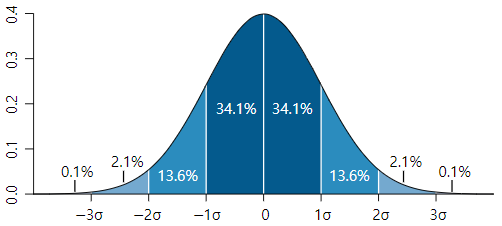
  * 좌우 대칭형의 종모양.
  * 연속확률함수
  * 평균 μ를 중심으로 높은 데이터 분포도 가짐
  * 좌우 표준편차 1에 전체 데이터의 68.27%, 좌우 표준편차 2에 94.45%를 가지고 있음
  * 표준 정규 분포 : 평균이 0, 표준편차가 1인 정규 분포
* 섞인 데이터 분포에서 개별 유형의 가우시안 분포 추출
* 모수 추정
  * 전체 데이터셋은 서로 다른 정규 분포 형태를 가진 여러 확률 분포 곡선으로 구성됨 -> 서로 다른 정규 분포에 기반해 군집화 수행 -> GMM 군집화 방식
  * 1천개의 데이터셋이 있다면 -> 구성하는 여러 개의 정규 분포 곡선 추출 -> 개별 데이터가 이 중 어떤 정규 분포에 속하는지 결정
  * 모수 추정이 추정하는 것
    * 개별 정규 분포의 평균과 분산
    * 각 데이터가 어떤 정규 분포에 해당되는지의 확률
  * 클러스터링하려는 데이터 분포 = 개별 정규 분포 찾기(개별 정규 분포의 평균과 분산) + 데이터가 특정 정규 분포에 해당될 확률 구하기
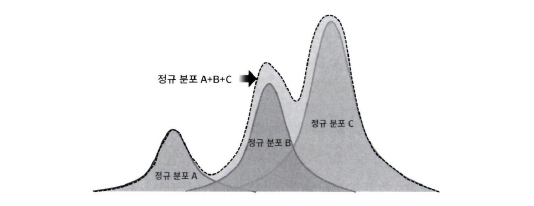
* 모수 추정 위해 GMM은 EM(Expecation and Maximization)방식 적용
* 사이킷런에서는 GMM의 EM 방식 통한 모수 추정 군집화로 GaussianMixture 클래스 지원

# GMM을 이용한 붓꽃 데이터 세트 군집화
* GMM = 확률 기반 군집화 <-> K-평균 = 거리 기반 군집화
* 붓꽃 데이터셋으로 둘을 비교
* GaussianMixture 객체 중요 파라미터 = n_components : gaussian mixture 모델의 총 개수 -> 군집의 개수를 정하는 데 중요한 역할

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target']=iris.target

In [4]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

#군집화 결과를 irisDF의 gmm_cluster 칼럼명으로 저장
irisDF['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

#target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result) #target1만 cluster 2개로 매핑됨 -> 앞절의 붓꽃데이터 셋의 K-평균 군집화 결과보다 더 효과적 결과 나옴

target  gmm_cluster
0       0              50
1       1              45
        2               5
2       2              50
Name: gmm_cluster, dtype: int64


In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       2                 48
        0                  2
2       0                 36
        2                 14
Name: kmeans_cluster, dtype: int64


* 어떤 알고리즘이 더 뛰어나다(X) 붓꽃 데이터 세트가 GMM 군집화에 더 효과적이다(O)
* K-평균은 평균 거리 중심으로 중심을 이동하며 군집화 수행 -> 개별 군집 내 데이터가 원형으로 흩어져 있을 때 매우 효과적

# GMM과 K-평균의 비교
* KMeans
  * 원형의 범위에서 군집화 수행 -> 원형 범위 가질수록 군집화 효율 높아짐 // 길쭉한 타원형으로 늘어서면 군집화 잘 수행 안됨
  * make)blobs()에서 cluster_std를 0.5로 군집 내의 데이터를 뭉치게 유도 -> cluster_std 작게 설정하면 데이터가 원형 형태로 분산됨
* 자세한 소스코드는 부록에
* GMM
  * KMeans보다 유연하게 다양한 데이터셋에 잘 적용됨
  * 군집화 수행시간 오래 걸림